# **Fixed Learning rate**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9227 - loss: 0.2642 - val_accuracy: 0.9573 - val_loss: 0.1537
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9666 - loss: 0.1110 - val_accuracy: 0.9668 - val_loss: 0.1078
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9756 - loss: 0.0788 - val_accuracy: 0.9701 - val_loss: 0.1026
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9814 - loss: 0.0579 - val_accuracy: 0.9722 - val_loss: 0.0956
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9852 - loss: 0.0456 - val_accuracy: 0.9721 - val_loss: 0.1042
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9887 - loss: 0.0357 - val_accuracy: 0.9720 - val_loss: 0.0996
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9898 - loss: 0.0310 - val_accuracy: 0.9749 - val_loss: 0.1035
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9919 - loss: 0.0259 -

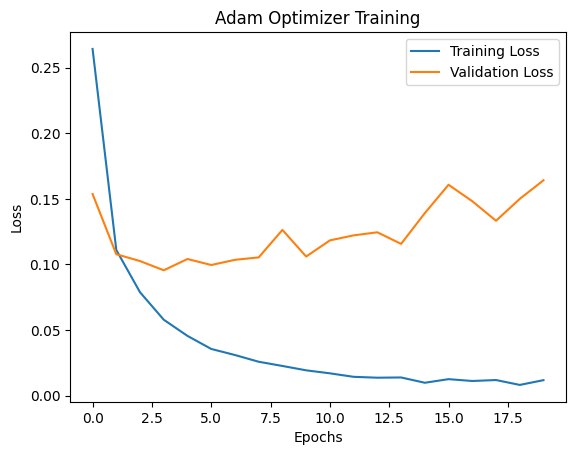

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

adam_lr = 0.001

optimizer = keras.optimizers.Adam(learning_rate=adam_lr)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Adam Optimizer Training")
plt.show()

# **Step decay**

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8570 - loss: 0.4901 - val_accuracy: 0.9566 - val_loss: 0.1494 - learning_rate: 0.0010
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9652 - loss: 0.1202 - val_accuracy: 0.9652 - val_loss: 0.1130 - learning_rate: 0.0010
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9774 - loss: 0.0750 - val_accuracy: 0.9678 - val_loss: 0.1043 - learning_rate: 0.0010
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9826 - loss: 0.0557 - val_accuracy: 0.9749 - val_loss: 0.0878 - learning_rate: 0.0010
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9863 - loss: 0.0433 - val_accuracy: 0.9728 - val_loss: 0.0971 - learning_rate: 0.0010
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9924 - loss: 0.0251 - val_accuracy: 0.9775 - val_loss: 0.0838 - learning_rate: 5.0000e-04
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9958

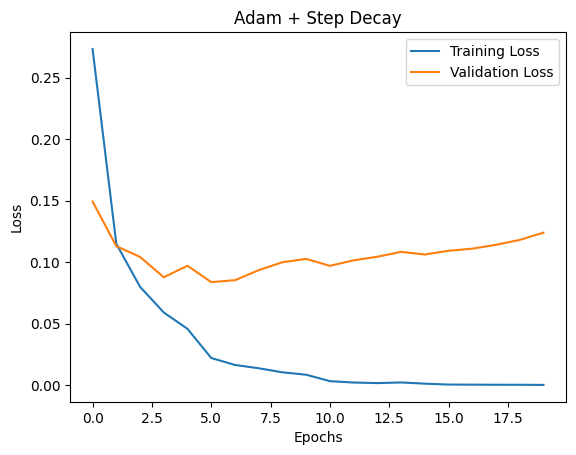

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0


model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


initial_lr = 0.001

optimizer = keras.optimizers.Adam(learning_rate=initial_lr)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

def step_decay(epoch, lr):
    drop_rate = 0.5
    epochs_drop = 5

    if epoch > 0 and epoch % epochs_drop == 0:
        return lr * drop_rate
    return lr

lr_scheduler = keras.callbacks.LearningRateScheduler(step_decay)


history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[lr_scheduler]
)


test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Adam + Step Decay")
plt.show()

# **Exponential Decay**

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8632 - loss: 0.4765 - val_accuracy: 0.9580 - val_loss: 0.1393
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9662 - loss: 0.1152 - val_accuracy: 0.9678 - val_loss: 0.1069
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9780 - loss: 0.0750 - val_accuracy: 0.9679 - val_loss: 0.1066
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9835 - loss: 0.0546 - val_accuracy: 0.9736 - val_loss: 0.0842
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9883 - loss: 0.0376 - val_accuracy: 0.9757 - val_loss: 0.0809
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9934 - loss: 0.0246 - val_accuracy: 0.9741 - val_loss: 0.0867
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9950 - loss: 0.0191 - val_accuracy: 0.9736 - val_loss: 0.0914
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9970 - loss: 0.0130 - 

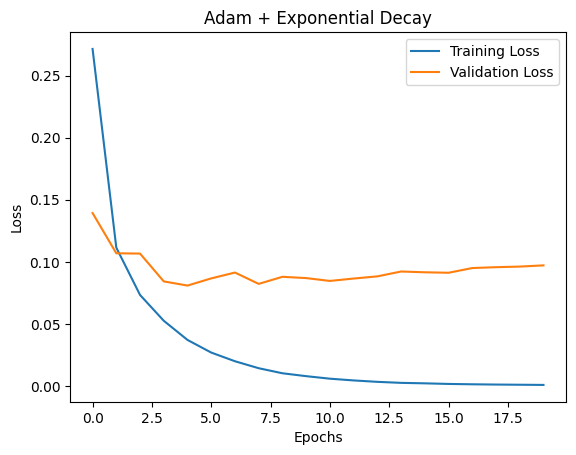

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


x_train = x_train / 255.0
x_test = x_test / 255.0


model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

initial_lr = 0.001   # Adam sathi normally smaller LR use karto

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_lr,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=False
)

optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)


model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2
)


test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Adam + Exponential Decay")
plt.show()

# **Early Stopping step decay**

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8696 - loss: 0.4685 - val_accuracy: 0.9621 - val_loss: 0.1373 - learning_rate: 0.0010
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9666 - loss: 0.1133 - val_accuracy: 0.9634 - val_loss: 0.1171 - learning_rate: 0.0010
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9764 - loss: 0.0764 - val_accuracy: 0.9683 - val_loss: 0.1054 - learning_rate: 0.0010
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9823 - loss: 0.0581 - val_accuracy: 0.9725 - val_loss: 0.0978 - learning_rate: 0.0010
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9873 - loss: 0.0390 - val_accuracy: 0.9742 - val_loss: 0.0952 - learning_rate: 0.0010
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9931 - loss: 0.0220 - val_accuracy: 0.9766 - val_loss: 0.0836 - learning_rate: 5.0000e-04
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9961

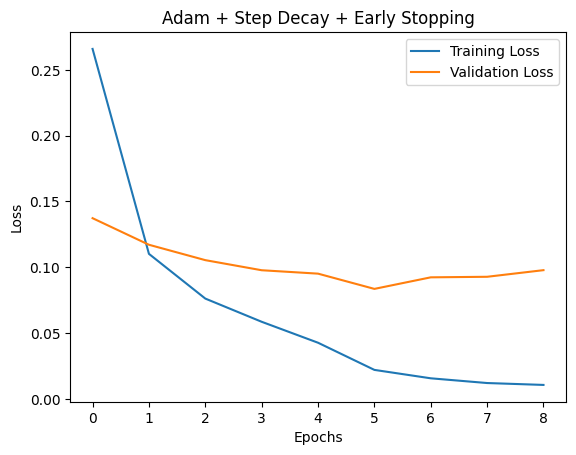

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


initial_lr = 0.001
optimizer = keras.optimizers.Adam(learning_rate=initial_lr)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

def step_decay(epoch, lr):
    drop_rate = 0.5
    epochs_drop = 5
    if epoch > 0 and epoch % epochs_drop == 0:
        return lr * drop_rate
    return lr

lr_scheduler = keras.callbacks.LearningRateScheduler(step_decay)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',     # watch validation loss
    patience=3,             # wait 3 epochs
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    epochs=30,
    validation_split=0.2,
    callbacks=[lr_scheduler, early_stopping]
)


test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Adam + Step Decay + Early Stopping")
plt.show()

# **Early stopping exponential**

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8649 - loss: 0.4662 - val_accuracy: 0.9534 - val_loss: 0.1465
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9638 - loss: 0.1199 - val_accuracy: 0.9647 - val_loss: 0.1170
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9759 - loss: 0.0792 - val_accuracy: 0.9695 - val_loss: 0.0978
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9839 - loss: 0.0547 - val_accuracy: 0.9743 - val_loss: 0.0850
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9883 - loss: 0.0362 - val_accuracy: 0.9731 - val_loss: 0.0878
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9910 - loss: 0.0298 - val_accuracy: 0.9744 - val_loss: 0.0871
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9950 - loss: 0.0201 - val_accuracy: 0.9755 - val_loss: 0.0857
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9727 - loss: 0.0851
Test Accuracy: 

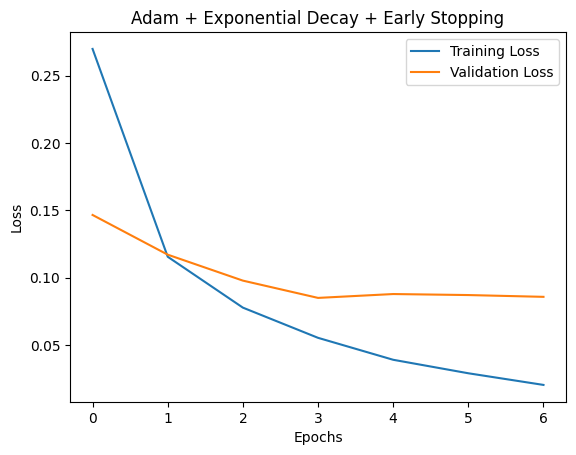

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

initial_lr = 0.001

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_lr,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=False
)


optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stopping]
)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Adam + Exponential Decay + Early Stopping")
plt.show()